### Problem Statement:

One of the aspects Seattle is most notable for, in addition to coffee, grunge, and electronic businesses, is its rains. From January 1, 1948 to December 12, 2017, this dataset provides full records of Seattle's daily rainfall patterns.

### Data Dictionary

- Following are the variables with their definition and key:

    - DATE: The date of the observation

    - PRCP: The amount of precipitation, in inches

    - TMAX: The maximum temperature for that day, in degrees Fahrenheit

    - TMIN: The minimum temperature for that day, in degrees Fahrenheit

    - RAIN: TRUE if rain was observed on that day, FALSE if it was not

#### 1) Importing Necessary Libraries:

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.base import BaseEstimator, TransformerMixin

#### 2) Loading Data:

In [3]:
df = pd.read_csv('seattleWeather_1948-2017.csv')

In [4]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [5]:
df.shape

(25551, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [7]:
df.describe()

,PRCP,TMAX,TMIN
count,25548.000000,25551.000000,25551.000000
mean,0.106222,59.544206,44.514226
std,0.239031,12.772984,8.892836
min,0.000000,4.000000,0.000000
25%,0.000000,50.000000,38.000000
50%,0.000000,58.000000,45.000000
75%,0.100000,69.000000,52.000000
max,5.020000,103.000000,71.000000


#### 3) Data Cleaning and Transformations:

In [8]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


##### 1) Handling Missing Values:

In [9]:
df.isna().sum() / len(df) * 100

DATE    0.000000
PRCP    0.011741
TMAX    0.000000
TMIN    0.000000
RAIN    0.011741
dtype: float64

- There are 3 Missing Values for "PRCP" and 'RAIN' columns.

In [10]:
df[df['PRCP'].isna()]

,DATE,PRCP,TMAX,TMIN,RAIN
18415,1998-06-02,NaN,72,52,NaN
18416,1998-06-03,NaN,66,51,NaN
21067,2005-09-05,NaN,70,52,NaN


- As we can see, Same 3 rows has 'PRCP' and 'RAIN' features missing.
- We can drop this 3 rows.

In [11]:
df = df.dropna()

In [12]:
df.isna().sum()

DATE    0
PRCP    0
TMAX    0
TMIN    0
RAIN    0
dtype: int64

- Missing Values are Taken Care of.
- For all the features, we will go feature by feature to check what king of Transformations are needed.

##### 2) DATE:

In [14]:
df['DATE']

0        1948-01-01
1        1948-01-02
2        1948-01-03
3        1948-01-04
4        1948-01-05
            ...    
25546    2017-12-10
25547    2017-12-11
25548    2017-12-12
25549    2017-12-13
25550    2017-12-14
Name: DATE, Length: 25548, dtype: object

- The DATE column itself won't be useful in Model Building.
- We will extract Day, Month, Year from DATE value and then drop the date column.
- Finally, we will One Hot Encode Day, Month and Year features.

In [15]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts Day, Month and Year from Date Column.
    """

    def __init__(self, date_column):
        self.date_column = date_column

    def fit(self, X, y= None):
        return self

    def transform(self, X):

        X = X.copy()

        # Confirming that DATE column is in DATETIME Datatype
        X[self.date_column] = pd.to_datetime(X[self.date_column], errors= 'coerce')

        X[f'{self.date_column}_Year'] = X[self.date_column].dt.year
        X[f'{self.date_column}_Month'] = X[self.date_column].dt.month
        X[f'{self.date_column}_Day'] = X[self.date_column].dt.day

        X = X.drop(self.date_column, axis= 1) # Dropping Original Date Column

        return X

In [18]:
# Preprocessing Pipeline:

date_pipeline = Pipeline([
    ('feature_extractor', DateFeatureExtractor('DATE')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 3) PRCP:

In [21]:
df['PRCP']

0        0.47
1        0.59
2        0.42
3        0.31
4        0.17
         ... 
25546    0.00
25547    0.00
25548    0.00
25549    0.00
25550    0.00
Name: PRCP, Length: 25548, dtype: float64

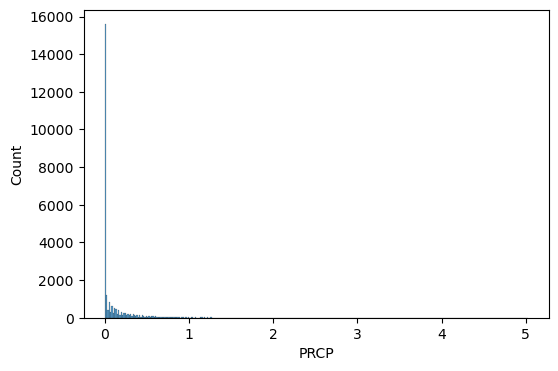

In [23]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'PRCP')
plt.show()

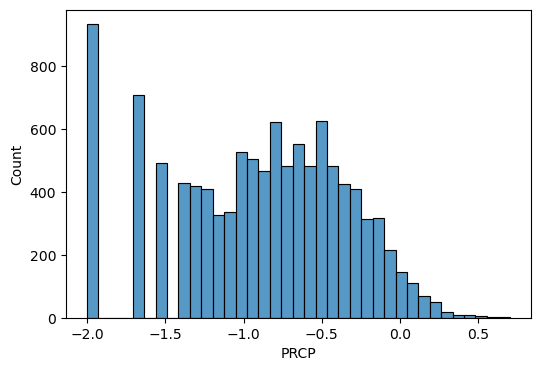

In [30]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['PRCP'].apply(np.log10))
plt.show()

In [33]:
# Preprocessing Pipeline:

prcp_pipeline = Pipeline([
    ('transformer', FunctionTransformer(lambda x: np.log10(np.where(X <= 0, np.nan, x)))), # To take care of -inf
    ('imputer', SimpleImputer(strategy= 'median')), # To take care of Null values created in above step
    ('scaler', StandardScaler())
])

##### 4) TMAX:

In [35]:
df['TMAX']

0        51
1        45
2        45
3        45
4        45
         ..
25546    49
25547    49
25548    46
25549    48
25550    50
Name: TMAX, Length: 25548, dtype: int64

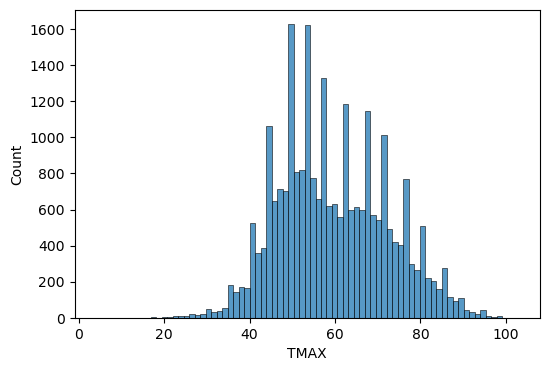

In [36]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'TMAX')
plt.show()

- Distribution of 'TMAX' seems close enough to Normal Distribution.
- No need for any transformations except Scaling.

In [47]:
# Preprocessing Pipeline:

tmax_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 5) TMIN:

In [37]:
df['TMIN']

0        42
1        36
2        35
3        34
4        32
         ..
25546    34
25547    29
25548    32
25549    34
25550    36
Name: TMIN, Length: 25548, dtype: int64

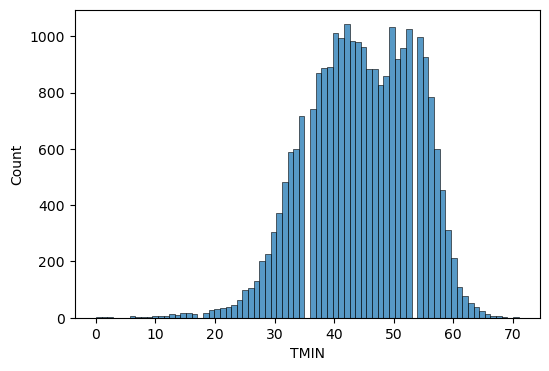

In [38]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'TMIN')
plt.show()

- Distribution of 'TMIN' seems close enough to Normal Distribution.
- No need for any transformations except Scaling.

In [45]:
# Preprocessing Pipeline:

tmin_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

#### 4) Final Column Transformer:

In [48]:
preprocessor = ColumnTransformer([
    ('Date', date_pipeline, ['DATE']),
    ('PRCP', prcp_pipeline, ['PRCP']),
    ('TMAX', tmax_pipeline, ['TMAX']),
    ('TMIN', tmin_pipeline, ['TMIN'])
])

#### 5) Train Test Split:

In [49]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [50]:
X = df.drop('RAIN',axis= 1) # Features
y = df['RAIN'] # Target

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [54]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20438, 4)
(5110, 4)
(20438,)
(5110,)
